In [1]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn import datasets
from sklearn.model_selection import GridSearchCV
import pandas as pd 
import numpy as np
import shap

c:\Users\Claudio\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_excel('Working Version - default of credit card clients.xls',header=1)
df = pd.DataFrame(df)
df

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,PAY_AMT5,PAY_AMT6,default payment next month,UTIL_t1,UTIL_t2,UTIL_t3,UTIL_t4,UTIL_t5,UTIL_t6,Average of Util Over 6 Months
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,1,0.195650,0.155100,0.034450,0.000000,0.000000,0.000000,0.064200
1,2,120000,2,2,2,26,-1,2,0,0,...,0,2000,1,0.022350,0.014375,0.022350,0.027267,0.028792,0.027175,0.023718
2,3,90000,2,2,2,34,0,0,0,0,...,1000,5000,0,0.324878,0.155856,0.150656,0.159233,0.166089,0.172767,0.188246
3,4,50000,2,2,1,37,0,0,0,0,...,1069,1000,0,0.939800,0.964660,0.985820,0.566280,0.579180,0.590940,0.771113
4,5,50000,1,2,1,57,-1,0,-1,0,...,689,679,0,0.172340,0.113400,0.716700,0.418800,0.382920,0.382620,0.364463
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,29996,220000,1,3,1,39,0,0,0,0,...,5000,1000,0,0.858855,0.876432,0.947114,0.400018,0.141986,0.072636,0.549507
29996,29997,150000,1,3,2,43,-1,-1,-1,-1,...,0,0,0,0.011220,0.012187,0.023347,0.059860,0.034600,0.000000,0.023536
29997,29998,30000,1,2,2,37,4,3,2,-1,...,2000,3100,1,0.118833,0.111867,0.091933,0.695933,0.686067,0.645233,0.391644
29998,29999,80000,1,3,1,41,1,-1,0,0,...,52964,1804,1,-0.020563,0.979738,0.953800,0.659675,0.148187,0.611800,0.555440


In [3]:
X = df.loc[:,df.columns != 'default payment next month'].copy()
X = pd.DataFrame(X)
Y = df.loc[:,'default payment next month'].values.copy()


#To be one hot encoded
XC = X.loc[:,['SEX','EDUCATION','MARRIAGE','PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6']].values
XC

#To be scaled normallly -> N(0,1)
X = X.loc[:, ~X.columns.isin(['SEX','EDUCATION','MARRIAGE','PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6', 
'Average of Util Over 6 Months', 
'ID'])].values

#Scaling for variables
scaler = StandardScaler()
cate = OneHotEncoder()
X = scaler.fit_transform(X)
XC = cate.fit_transform(XC)

XC = XC.toarray()
X_combined = np.hstack([X, XC])



In [9]:

x_trainv, x_test, y_trainv, y_test = train_test_split(X_combined, Y, test_size=0.1,stratify=Y, random_state = 28)

x_train, x_v, y_train, y_v = train_test_split(x_trainv, y_trainv, test_size=0.222, stratify=y_trainv, random_state = 28)

x_v = torch.tensor(x_v,dtype=torch.float32)
y_v = torch.tensor(y_v,dtype=torch.float32).view(-1, 1)

x_train = torch.tensor(x_train,dtype=torch.float32)
y_train = torch.tensor(y_train,dtype=torch.float32).view(-1, 1)

x_test = torch.tensor(x_test,dtype=torch.float32)
y_test = torch.tensor(y_test,dtype=torch.float32).view(-1, 1)


In [10]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(97, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

model = Net()

pos_weight = torch.tensor([3.0])
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

model.net[-1] = nn.Identity()

optimizer = optim.AdamW(model.parameters(), lr=1e-3)

In [12]:
epochs = 50
patience = 10
best_val_loss = float('inf')
counter = 0

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()

    outputs = model(x_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()


    model.eval()
    with torch.no_grad():
        val_outputs = model(x_v)
        val_loss = criterion(val_outputs, y_v)

    print(f"Epoch {epoch+1}: Train Loss={loss.item():.4f}, Val Loss={val_loss.item():.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
        best_model_state = model.state_dict()
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered.")
            break

model.load_state_dict(best_model_state)

Epoch 1: Train Loss=1.0237, Val Loss=0.9960
Epoch 2: Train Loss=0.9925, Val Loss=0.9911
Epoch 3: Train Loss=0.9687, Val Loss=0.9858
Epoch 4: Train Loss=0.9533, Val Loss=0.9802
Epoch 5: Train Loss=0.9366, Val Loss=0.9743
Epoch 6: Train Loss=0.9269, Val Loss=0.9681
Epoch 7: Train Loss=0.9093, Val Loss=0.9616
Epoch 8: Train Loss=0.9039, Val Loss=0.9547
Epoch 9: Train Loss=0.8920, Val Loss=0.9476
Epoch 10: Train Loss=0.8846, Val Loss=0.9402
Epoch 11: Train Loss=0.8788, Val Loss=0.9325
Epoch 12: Train Loss=0.8747, Val Loss=0.9246
Epoch 13: Train Loss=0.8640, Val Loss=0.9164
Epoch 14: Train Loss=0.8603, Val Loss=0.9082
Epoch 15: Train Loss=0.8560, Val Loss=0.8999
Epoch 16: Train Loss=0.8518, Val Loss=0.8916
Epoch 17: Train Loss=0.8499, Val Loss=0.8836
Epoch 18: Train Loss=0.8446, Val Loss=0.8759
Epoch 19: Train Loss=0.8435, Val Loss=0.8686
Epoch 20: Train Loss=0.8396, Val Loss=0.8618
Epoch 21: Train Loss=0.8330, Val Loss=0.8555
Epoch 22: Train Loss=0.8376, Val Loss=0.8500
Epoch 23: Train Los

<All keys matched successfully>

In [13]:
model.eval()
with torch.no_grad():
    # ----- VALIDATION -----
    val_outputs = model(x_v)
    val_probs = torch.sigmoid(val_outputs).cpu().numpy()
    y_predval = (val_probs > 0.5).astype(int)
    y_v_np = y_v.cpu().numpy()


    print("----- VALIDATION METRICS -----")
    print(f"Accuracy : {accuracy_score(y_v_np, y_predval):.4f}")
    print(f"Precision: {precision_score(y_v_np, y_predval):.4f}")
    print(f"Recall   : {recall_score(y_v_np, y_predval):.4f}")
    print(f"F1 Score : {f1_score(y_v_np, y_predval):.4f}")
    print(f"ROC AUC  : {roc_auc_score(y_v_np, val_probs):.4f}")

    # ----- TEST -----
    test_outputs = model(x_test)
    test_probs = torch.sigmoid(test_outputs).cpu().numpy()
    y_predtest = (test_probs > 0.5).astype(int)
    y_test_np = y_test.cpu().numpy()

    print("\n----- TEST METRICS -----")
    print(f"Accuracy : {accuracy_score(y_test_np, y_predtest):.4f}")
    print(f"Precision: {precision_score(y_test_np, y_predtest):.4f}")
    print(f"Recall   : {recall_score(y_test_np, y_predtest):.4f}")
    print(f"F1 Score : {f1_score(y_test_np, y_predtest):.4f}")
    print(f"ROC AUC  : {roc_auc_score(y_test_np, test_probs):.4f}")



----- VALIDATION METRICS -----
Accuracy : 0.7643
Precision: 0.4750
Recall   : 0.6229
F1 Score : 0.5390
ROC AUC  : 0.7788

----- TEST METRICS -----
Accuracy : 0.7730
Precision: 0.4901
Recall   : 0.6325
F1 Score : 0.5523
ROC AUC  : 0.7880


SHAP values shape: (100, 97)
X_test shape     : (100, 97)


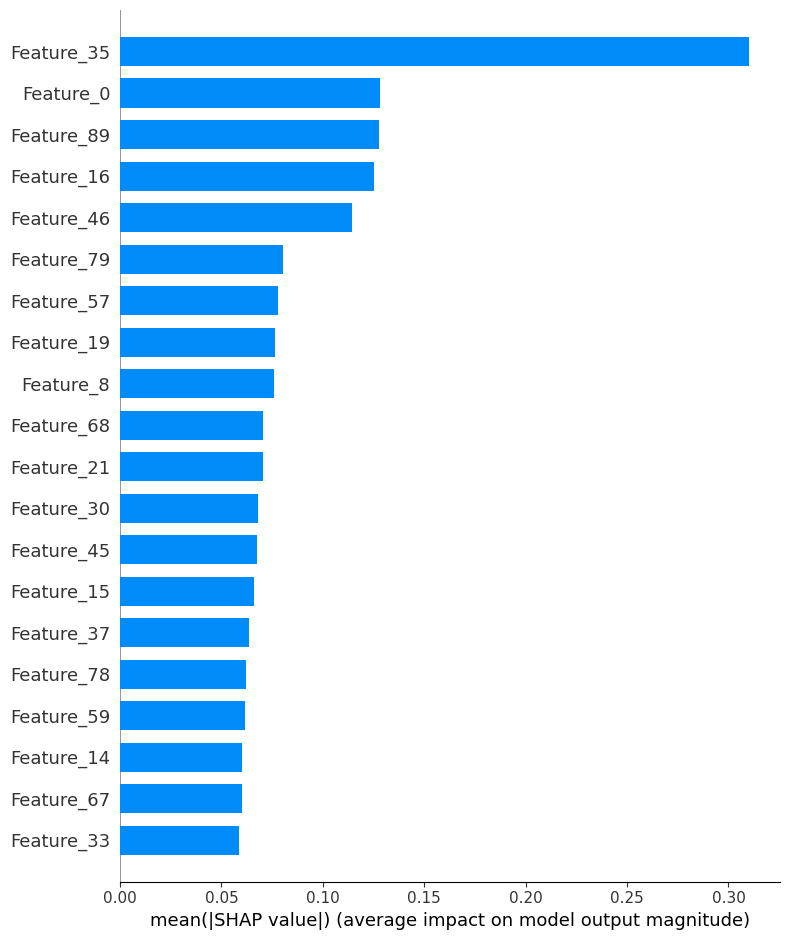

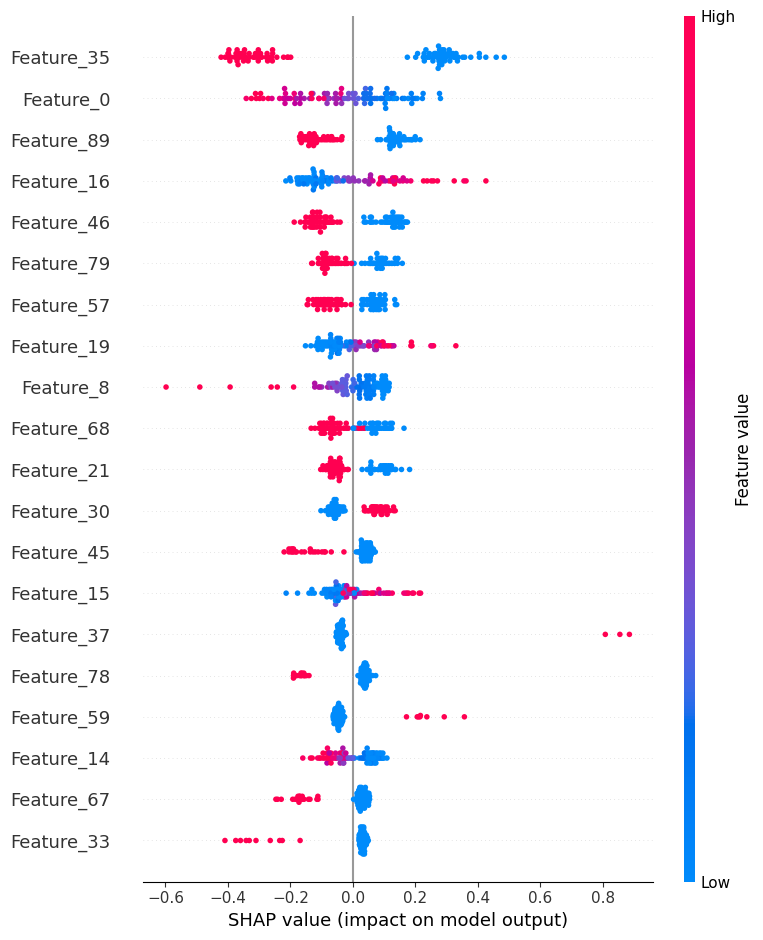

In [18]:
# Fixed SHAP for MLP - handles shape issues
model.eval()

# x_train and x_test are already tensors in this notebook
X_train_sample = x_train[:200]
X_test_sample = x_test[:100]

# DeepExplainer works with PyTorch models
explainer = shap.DeepExplainer(model, X_train_sample)
shap_values = explainer.shap_values(X_test_sample)

# DeepExplainer returns shape (100, 97, 1) for single output MLP
# Squeeze the last dimension to get (100, 97)
shap_vals_np = shap_values[:, :, 0]
X_test_np = X_test_sample.detach().numpy()

print(f"SHAP values shape: {shap_vals_np.shape}")
print(f"X_test shape     : {X_test_np.shape}")

# Feature names
feature_names = [f"Feature_{i}" for i in range(X_test_np.shape[1])]

# Global bar plot - mean absolute SHAP value per feature
shap.summary_plot(shap_vals_np, X_test_np,
                  feature_names=feature_names,
                  plot_type="bar",
                  max_display=20,
                  show=True)

# Beeswarm plot - direction and distribution of SHAP values
shap.summary_plot(shap_vals_np, X_test_np,
                  feature_names=feature_names,
                  max_display=20,
                  show=True)



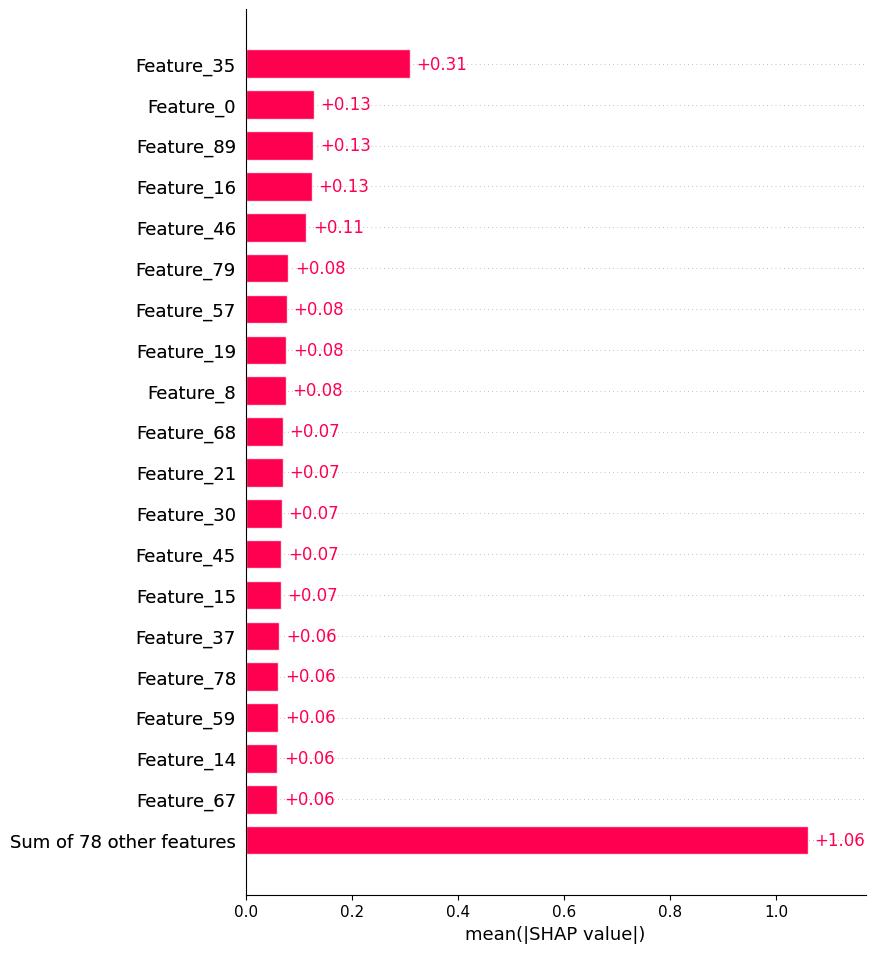

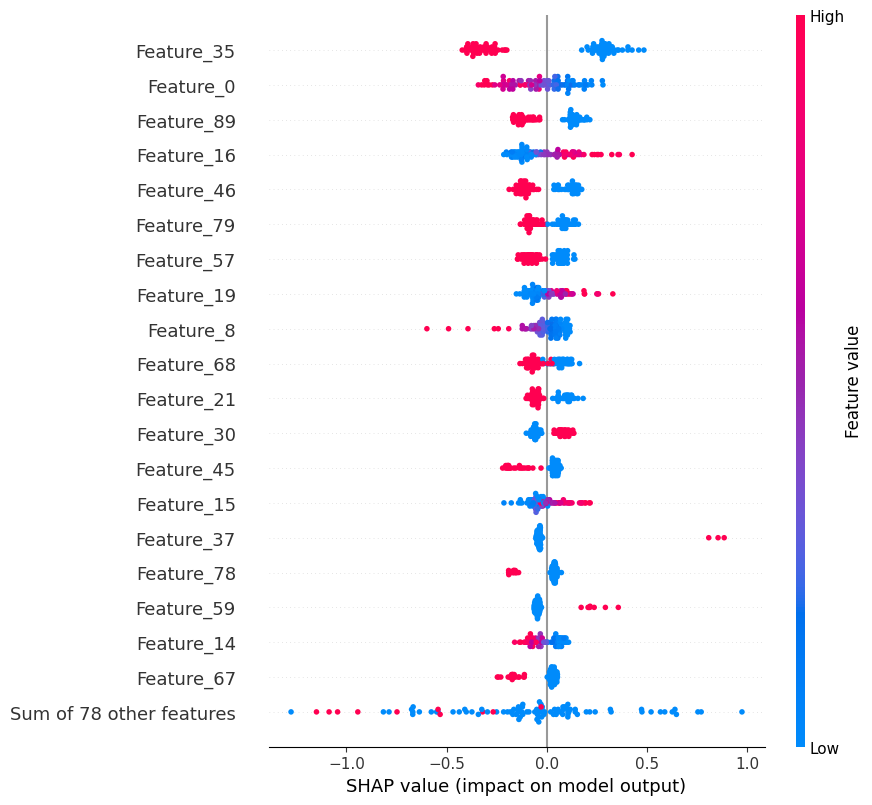

In [ ]:
# Rename features for readable SHAP plot

feature_name_map = {
    'X1': 'LIMIT_BAL',
    'X2': 'SEX',
    'X3': 'EDUCATION',
    'X4': 'MARRIAGE',
    'X5': 'AGE',
    'X6': 'PAY_0',
    'X7': 'PAY_2',
    'X8': 'PAY_3',
    'X9': 'PAY_4',
    'X10': 'PAY_5',
    'X11': 'PAY_6',
    'X12': 'BILL_AMT1',
    'X13': 'BILL_AMT2',
    'X14': 'BILL_AMT3',
    'X15': 'BILL_AMT4',
    'X16': 'BILL_AMT5',
    'X17': 'BILL_AMT6',
    'X18': 'PAY_AMT1',
    'X19': 'PAY_AMT2',
    'X20': 'PAY_AMT3',
    'X21': 'PAY_AMT4',
    'X22': 'PAY_AMT5',
    'X23': 'PAY_AMT6'
}

# MLP has 97 features after one-hot encoding
# Generate feature names for all 97 columns
feature_names_mlp = mlp_feature_names

# Rebuild explanation using MLP variable names
shap_explanation_named = shap.Explanation(
    values=shap_vals_np,
    base_values=np.zeros(shap_vals_np.shape[0]),
    data=X_test_np,
    feature_names=feature_names_mlp
)

# Replot with names
shap.plots.bar(shap_explanation_named,
               max_display=20,
               show=True)

shap.plots.beeswarm(shap_explanation_named,
                    max_display=20,
                    show=True)

In [21]:


# Counterfactual Helper Function
# Takes a dataset, applies an intervention, returns the mean change in predicted default probability

def run_intervention(model, X_original, intervention_fn, label):
    """
    intervention_fn: a function that takes a copy of X and 
                     returns the modified version
    """
    X_modified = intervention_fn(X_original.copy())
    
    prob_original = model.predict_proba(X_original)[:, 1]
    prob_modified = model.predict_proba(X_modified)[:, 1]
    
    delta_p = prob_modified - prob_original  # negative = reduction
    
    print(f"\n--- {label} ---")
    print(f"Mean ΔP(default)       : {delta_p.mean():.6f}")
    print(f"Mean |ΔP(default)|     : {np.abs(delta_p).mean():.6f}")
    print(f"Clients with reduction : "
          f"{(delta_p < 0).sum()} / {len(delta_p)}")
    
    return delta_p



In [24]:
# Intervention A: Reduce Bill Amounts (Reduce Utilization)
# Simulate clients paying down their balance by 10%, 25%, 50%
# LIMIT_BAL (X1) stays the same, only BILL_AMTs change -- Utilization ratios are recomputed after the change

results_A = {}

for pct in [0.10, 0.25, 0.50]:
    def intervention_A(X, reduction=pct):
        X_mod = X.copy()
        # Reduce each bill amount column
        for col in bill_cols:
            X_mod[col] = X_mod[col] * (1 - reduction)
        # Recompute utilization ratios
        for bill, util in zip(bill_cols, util_col_names):
            X_mod[util] = X_mod[bill] / X_mod['X1'].replace(0, np.nan)
        X_mod['UTIL_avg'] = X_mod[util_col_names].mean(axis=1)
        # Clip to training min/max
        for col in bill_cols + util_col_names + ['UTIL_avg']:
            X_mod[col] = X_mod[col].clip(
                X_train[col].min(), X_train[col].max()
            )
        return X_mod
    
    delta = run_intervention(
        model, x_test, intervention_A,
        f"Intervention A - Reduce Bill Amounts by {int(pct*100)}%"
    )
    results_A[pct] = delta

AttributeError: 'Tensor' object has no attribute 'copy'

In [ ]:
#  Intervention B: Increase Credit Limit
# Simulate lender increasing LIMIT_BAL (X1) by 10%, 25%, 50% -- Bill amounts stay the same, utilization ratios recomputed

results_B = {}

for pct in [0.10, 0.25, 0.50]:
    def intervention_B(X, increase=pct):
        X_mod = X.copy()
        # Increase credit limit
        X_mod['X1'] = X_mod['X1'] * (1 + increase)
        # Recompute utilization ratios with new limit
        for bill, util in zip(bill_cols, util_col_names):
            X_mod[util] = X_mod[bill] / X_mod['X1'].replace(0, np.nan)
        X_mod['UTIL_avg'] = X_mod[util_col_names].mean(axis=1)
        # Clip to training distribution
        for col in ['X1'] + util_col_names + ['UTIL_avg']:
            X_mod[col] = X_mod[col].clip(
                X_train[col].min(), X_train[col].max()
            )
        return X_mod
    
    delta = run_intervention(
        rf_model, X_test, intervention_B,
        f"Intervention B - Increase Credit Limit by {int(pct*100)}%"
    )
    results_B[pct] = delta

In [ ]:
# Summary Comparison Plot
# Line chart of mean |ΔP| vs intervention level for all three interventions

levels = [0.10, 0.25, 0.50]
labels = ['10%', '25%', '50%']

mean_A = [np.abs(results_A[p]).mean() for p in levels]
mean_B = [np.abs(results_B[p]).mean() for p in levels]
mean_C = [np.abs(results_C[p]).mean() for p in levels]

plt.figure(figsize=(8, 5))
plt.plot(labels, mean_A, marker='o', label='A: Reduce Bill Amounts')
plt.plot(labels, mean_B, marker='s', label='B: Increase Credit Limit')
plt.plot(labels, mean_C, marker='^', 
         label='C: Increase Limit (Util Constant)')
plt.xlabel('Intervention Level')
plt.ylabel('Mean |ΔP(default)|')
plt.title('Random Forest: Mean Change in Predicted Default Probability\n'
          'by Intervention Type and Level')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('MLP_counterfactual_comparison.png', dpi=150)
plt.show()

In [ ]:
# Client Segmentation Analysis

baseline_probs = model.predict_proba(X_test)[:, 1]

high_risk_mask = baseline_probs > 0.5
low_risk_mask  = baseline_probs < 0.4  # lowered from 0.2

print(f"High-risk clients (P > 0.5): {high_risk_mask.sum()}")
print(f"Low-risk clients  (P < 0.4): {low_risk_mask.sum()}")

for mask, group_label in [(high_risk_mask, 'High-Risk'),
                           (low_risk_mask,  'Low-Risk')]:
    X_group = X_test[mask]
    
    # Skip if group is empty
    if len(X_group) == 0:
        print(f"\n{group_label} group is empty, skipping.")
        continue
        
    print(f"\n=== {group_label} Group (n={len(X_group)}) ===")

    def int_A_seg(X):
        X_mod = X.copy()
        for col in bill_cols:
            X_mod[col] = X_mod[col] * 0.75
        for bill, util in zip(bill_cols, util_col_names):
            X_mod[util] = X_mod[bill] / X_mod['X1'].replace(0, np.nan)
        X_mod['UTIL_avg'] = X_mod[util_col_names].mean(axis=1)
        for col in bill_cols + util_col_names + ['UTIL_avg']:
            X_mod[col] = X_mod[col].clip(
                X_train[col].min(), X_train[col].max()
            )
        return X_mod

    def int_B_seg(X):
        X_mod = X.copy()
        X_mod['X1'] = X_mod['X1'] * 1.25
        for bill, util in zip(bill_cols, util_col_names):
            X_mod[util] = X_mod[bill] / X_mod['X1'].replace(0, np.nan)
        X_mod['UTIL_avg'] = X_mod[util_col_names].mean(axis=1)
        for col in ['X1'] + util_col_names + ['UTIL_avg']:
            X_mod[col] = X_mod[col].clip(
                X_train[col].min(), X_train[col].max()
            )
        return X_mod

    run_intervention(rf_model, X_group, int_A_seg,
        f"{group_label} - Intervention A (25% bill reduction)")

    run_intervention(rf_model, X_group, int_B_seg,
        f"{group_label} - Intervention B (25% limit increase)")
    